### 1. Подготовка данных

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Модели и предобработка
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
# Метрики
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Балансировка
from imblearn.under_sampling import RandomUnderSampler

In [47]:
# Загрузка данных из Excel-файла
file_path = 'Деревья_в_лесу_по_наземным_данным_и_лидарные_предикторы.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

In [69]:
df.head()

,TreeID,H,D,Bereza,Eli,Iva,Lipa,Osina,Pihta,Porodclass,...,band6_mean,band7_mean,band1_med,band2_med,band3_med,band4_med,band5_med,band6_med,band7_med,target_binary
0,597,14,14,0,0,0,0,0,1,5,...,4152.990964,8982.554217,22489.5,30617.0,17592.0,1029.5,531.0,3929.0,8576.0,1.0
1,519,0,14,0,0,0,0,0,1,5,...,3189.383234,5628.431138,22261.0,29202.0,13674.0,951.0,501.0,3085.0,5573.0,1.0
2,516,0,16,0,0,0,0,0,1,5,...,3587.828452,6696.334728,25392.0,32490.0,19856.0,1096.0,637.0,3494.0,6413.0,1.0
3,624,0,16,0,0,0,0,0,1,5,...,3655.322430,8722.936137,24006.5,28691.0,16950.0,1022.5,610.0,3847.5,9185.0,1.0
4,663,0,16,0,0,0,0,0,1,5,...,3480.702929,7371.112971,21055.0,27855.0,13585.0,1002.0,514.0,3420.0,7210.0,1.0


In [68]:
df.describe()

,TreeID,H,D,Bereza,Eli,Iva,Lipa,Osina,Pihta,Porodclass,...,band6_mean,band7_mean,band1_med,band2_med,band3_med,band4_med,band5_med,band6_med,band7_med,target_binary
count,4706.000000,4706.000000,4706.000000,4706.000000,4706.000000,4706.000000,4706.000000,4706.000000,4706.000000,4706.00000,...,4706.000000,4706.000000,4706.000000,4706.000000,4706.000000,4706.000000,4706.000000,4706.00000,4706.000000,2305.000000
mean,2701.454739,3.564173,25.613685,0.510200,0.078411,0.003187,0.123247,0.273693,0.011262,1.60561,...,8352.410535,11240.514117,22631.883872,29371.853591,17542.427327,5146.330642,3377.458351,8287.31003,11282.721738,0.581779
std,1541.699758,8.431850,5.721553,0.499949,0.268845,0.056373,0.328755,0.445901,0.105536,1.81211,...,7395.717825,5139.897368,4771.982198,5103.341591,2717.757704,6760.735981,4578.232260,7428.10932,5284.685516,0.493374
min,1.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,1155.400000,2901.000000,4486.500000,8114.000000,8064.000000,340.000000,239.000000,1160.00000,2906.000000,0.000000
25%,1368.250000,0.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,3588.969440,7899.666667,19688.000000,26425.625000,15805.500000,938.500000,513.000000,3538.00000,7778.000000,0.000000
50%,2743.500000,0.000000,26.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,4329.461149,9307.864978,23066.500000,29897.000000,17595.000000,1101.000000,620.000000,4424.00000,9500.500000,1.000000
75%,4059.750000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4.00000,...,14309.670347,13582.278102,25938.500000,32887.000000,19276.000000,11017.625000,7513.500000,13275.87500,13062.000000,1.000000
max,5334.000000,32.000000,58.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.00000,...,33322.111047,31071.688687,39895.000000,45693.000000,33075.000000,30559.500000,17920.000000,35467.00000,32107.500000,1.000000


In [48]:
df.shape

(4706, 92)

### 2. Регрессия

In [49]:
# Подготовка данных
# Используем копию исходного датафрейма, чтобы не сломать логику классификации
df_reg = df.copy()

In [50]:
# Убедимся, что H=0 заменено на NaN (как в части классификации)
if 'H' in df_reg.columns:
    df_reg['H'] = df_reg['H'].replace(0, np.nan)

In [51]:
# Определяем целевую переменную
target_reg = 'D'

In [52]:
# Проверяем и очищаем целевую переменную от пропусков (обучать с NaN в таргете нельзя)
print(f"Пропуски в {target_reg} до очистки: {df_reg[target_reg].isnull().sum()}")
df_reg = df_reg.dropna(subset=[target_reg])
print(f"Пропуски в {target_reg} после очистки: {df_reg[target_reg].isnull().sum()}")

Пропуски в D до очистки: 0
Пропуски в D после очистки: 0


In [53]:
# Исключаем лишние колонки (ID, целевая, признаки класса, чтобы не было утечки данных)
cols_to_drop_reg = [
    'TreeID', target_reg, 'Porodclass', 'Porod2clas',
    'Bereza', 'Eli', 'Iva', 'Lipa', 'Osina', 'Pihta', 'class_name'
]

In [54]:
# Используем errors='ignore' на случай, если каких-то колонок уже нет в датасете
X_reg = df_reg.drop(columns=[c for c in cols_to_drop_reg if c in df_reg.columns])
y_reg = df_reg[target_reg]

In [55]:
# Разделение на обучающую и тестовую выборки (30% в тест для стабильности метрик)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
print(f"\nРазмер Train: {X_train_reg.shape}")
print(f"Размер Test:  {X_test_reg.shape}")


Размер Train: (3294, 82)
Размер Test:  (1412, 82)


In [56]:
# Создание пайплайна
pipeline_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Заполняем пропуски медианой
    ('scaler', StandardScaler()),                   # Масштабируем признаки
    ('regressor', Ridge(alpha=1.0, random_state=42)) # Регрессор с L2 регуляризацией
])

In [57]:
# Обучение модели
pipeline_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = pipeline_reg.predict(X_test_reg)

In [58]:
# Оценка качества
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("\nРезультаты регрессии (Diameter)")
print(f"MAE (Средняя абсолютная ошибка): {mae:.4f} см")
print(f"RMSE (Корень из ср. кв. ошибки): {rmse:.4f} см")
print(f"R2 (Коэффициент детерминации):   {r2:.4f}")


Результаты регрессии (Diameter)
MAE (Средняя абсолютная ошибка): 1.8216 см
RMSE (Корень из ср. кв. ошибки): 3.2827 см
R2 (Коэффициент детерминации):   0.6839


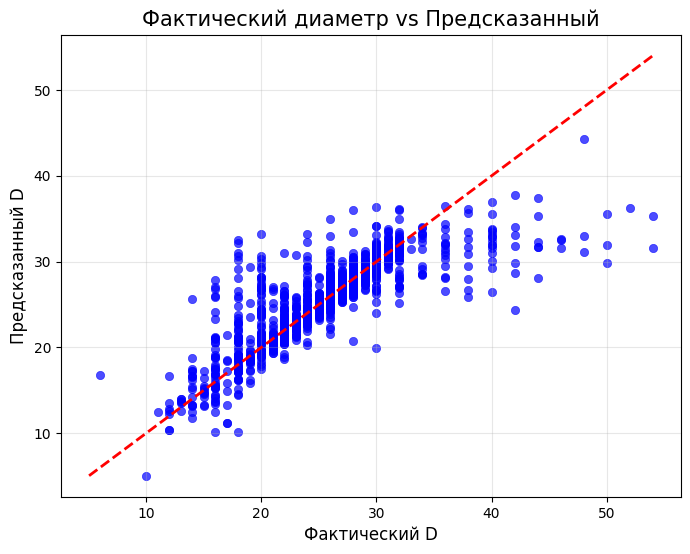

In [59]:
# Визуализация: Факт vs Предсказание
plt.figure(figsize=(8, 6))
# График рассеяния
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.7, edgecolor=None, color='blue')
# Идеальная линия (y = x)
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Фактический диаметр vs Предсказанный', fontsize=15)
plt.xlabel('Фактический D', fontsize=12)
plt.ylabel('Предсказанный D', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### 3. Классификация

Бинарная классификация деревьев: Хвойные (0) vs Лиственные (1)
Используется RandomUnderSampler для балансировки обучающей выборки

Уникальные классы в Porodclass: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Отфильтровано для бинарной задачи. Осталось строк: 2305
Распределение: 0(Хвойные)=964, 1(Лиственные)=1341


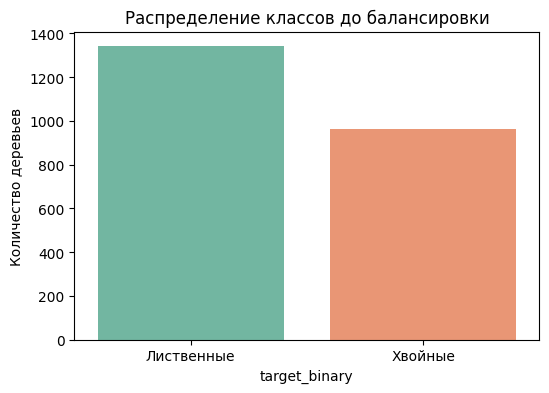

In [60]:
# Формирование бинарного таргета
CONIFEROUS_IDS = [1, 2, 3]   # Хвойные
DECIDUOUS_IDS = [4, 5, 6]    # Лиственные
RANDOM_STATE = 42
def map_to_binary(val):
    if val in CONIFEROUS_IDS: return 0
    if val in DECIDUOUS_IDS: return 1
    return np.nan

# Создаем колонку с бинарной меткой и отбрасываем строки с неизвестными классами
df['target_binary'] = df['Porodclass'].apply(map_to_binary)
df_bin = df.dropna(subset=['target_binary']).copy()
df_bin['target_binary'] = df_bin['target_binary'].astype(int)

print(f"Уникальные классы в Porodclass: {sorted(df['Porodclass'].unique())}")
print(f"Отфильтровано для бинарной задачи. Осталось строк: {df_bin.shape[0]}")
print(f"Распределение: 0(Хвойные)={sum(df_bin['target_binary']==0)}, 1(Лиственные)={sum(df_bin['target_binary']==1)}")

# Визуализация распределения до обработки
plt.figure(figsize=(6,4))
sns.countplot(x=df_bin['target_binary'].map({0: 'Хвойные', 1: 'Лиственные'}), palette='Set2')
plt.title('Распределение классов до балансировки')
plt.ylabel('Количество деревьев')
plt.show()

In [61]:
# Разделение на признаки и таргет + Train/Test Split
# Удаляем служебные и таргет-колонки
drop_cols = ['Porodclass', 'TreeID', 'Porod2clas', 'target_binary']
X = df_bin.drop(columns=[c for c in drop_cols if c in df_bin.columns], errors='ignore')
y = df_bin['target_binary']

# Сначала делим на train/test, ПОТОМ применяем undersampling (чтобы избежать data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print("Распределение в y_train:", dict(Counter(y_train)))


Train: (1728, 89), Test: (577, 89)
Распределение в y_train: {1: 1005, 0: 723}



Распределение после RandomUnderSampler: {0: 723, 1: 723}


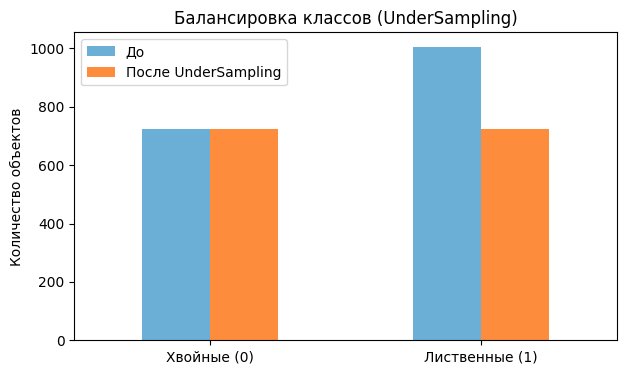

In [62]:
# Undersampling (Недосэмплирование)
# RandomUnderSampler случайно удаляет объекты мажоритарного класса,
# пока количества не сравняются с миноритарным
rus = RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy='auto')
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("\nРаспределение после RandomUnderSampler:", dict(Counter(y_train_under)))

# Визуализация до/после
stats = pd.DataFrame({
    'До': pd.Series(Counter(y_train)),
    'После UnderSampling': pd.Series(Counter(y_train_under))
}).fillna(0).astype(int)

stats.plot(kind='bar', figsize=(7,4), color=['#6baed6', '#fd8d3c'])
plt.title('Балансировка классов (UnderSampling)')
plt.ylabel('Количество объектов')
plt.xticks(ticks=[0, 1], labels=['Хвойные (0)', 'Лиственные (1)'], rotation=0)
plt.show()

Обучение моделей на сбалансированных данных...

Результаты моделей:


,Модель,Accuracy,Precision,Recall,F1,ROC-AUC
0,LogisticRegression,1.000000,1.000000,1.000000,1.000000,1.000000
1,DecisionTree,1.000000,1.000000,1.000000,1.000000,1.000000
2,RandomForest,0.998267,1.000000,0.997024,0.998510,1.000000
3,KNN,0.974003,0.987842,0.967262,0.977444,0.997987


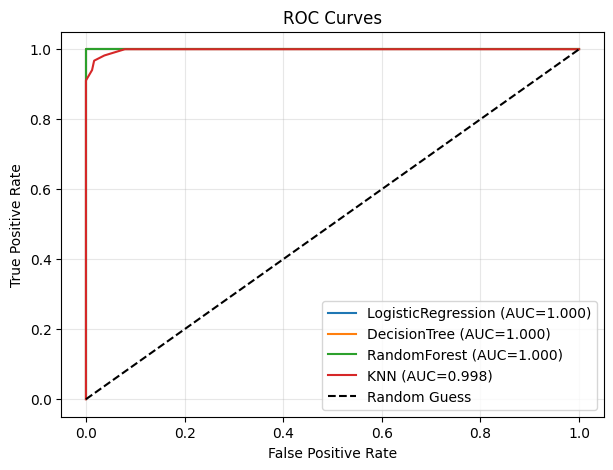

In [63]:
# Обучение моделей
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []
trained_models = {}

print("Обучение моделей на сбалансированных данных...")
for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train_under, y_train_under)
    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1] # Вероятность класса 1 для ROC-AUC

    results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

res_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("\nРезультаты моделей:")
display(res_df)

# Визуализация ROC-AUC
plt.figure(figsize=(7,5))
for idx, row in res_df.iterrows():
    name = row['Модель']
    auc_val = row['ROC-AUC']

    pipe = trained_models[name]
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


 Лучшая модель: LogisticRegression

 Classification Report:
                precision    recall  f1-score   support

   Хвойные (0)       1.00      1.00      1.00       241
Лиственные (1)       1.00      1.00      1.00       336

      accuracy                           1.00       577
     macro avg       1.00      1.00      1.00       577
  weighted avg       1.00      1.00      1.00       577



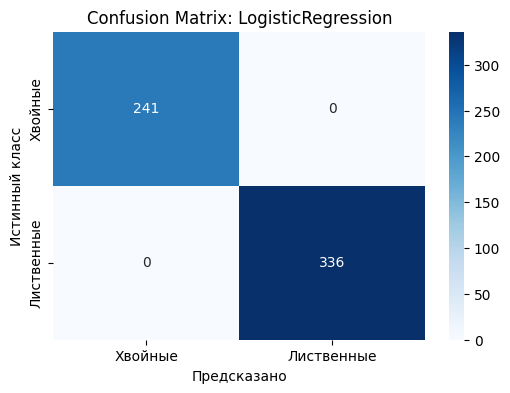

In [64]:
# Анализ лучшей модели
best_name = res_df.loc[0, 'Модель']
best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test)

print(f"\n Лучшая модель: {best_name}")
print("\n Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Хвойные (0)', 'Лиственные (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Хвойные', 'Лиственные'], yticklabels=['Хвойные', 'Лиственные'])
plt.title(f'Confusion Matrix: {best_name}')
plt.xlabel('Предсказано')
plt.ylabel('Истинный класс')
plt.show()

# Feature Importance (для деревьев)
if best_name in ['RandomForest', 'DecisionTree']:
    importances = best_model.named_steps['model'].feature_importances_
    feat_imp = pd.DataFrame({'feature': X.columns, 'importance': importances}) \
                 .sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(9,5))
    sns.barplot(data=feat_imp, y='feature', x='importance', orient='h', palette='viridis')
    plt.title(f'Топ-15 важных признаков ({best_name})')
    plt.xlabel('Важность (Gini/Information Gain)')
    plt.tight_layout()
    plt.show()


In [65]:
# Функция предсказания для новых данных
def predict_tree_type(model_pipeline, features_dict):
    """
    Принимает пайплайн и словарь признаков.
    Возвращает предсказанный класс и вероятности.
    """
    new_df = pd.DataFrame([features_dict])
    # Приводим порядок колонок к обученному
    missing = set(model_pipeline.named_steps['scaler'].feature_names_in_) - set(new_df.columns)
    for col in missing: new_df[col] = 0.0
    new_df = new_df[model_pipeline.named_steps['scaler'].feature_names_in_]

    pred = model_pipeline.predict(new_df)[0]
    prob = model_pipeline.predict_proba(new_df)[0]

    label = 'Хвойное' if pred == 0 else 'Лиственное'
    return {
        'Класс': label,
        'Вероятности': {'Хвойное': round(prob[0], 4), 'Лиственное': round(prob[1], 4)}
    }


In [66]:
new_tree_data = {
    'H': 25.5,           # Высота дерева (метры)
    'D': 32.0,           # Диаметр ствола (см)
    'Crown_Width': 4.5,  # Ширина кроны (метры) — *пример названия, замените на свое*
    'Lidar_Intensity': 1200, # Средняя интенсивность лидара — *пример названия*
    'n_points': 15000    # Количество точек облака
}

# Вызываем функцию предсказания
# Передаем обученную лучшую модель и данные дерева
result = predict_tree_type(best_model, new_tree_data)

# Выводим результат
print("-" * 40)
print("РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ")
print("-" * 40)
print(f" Тип дерева: {result['Класс']}")
print("\n Вероятности:")
for tree_type, probability in result['Вероятности'].items():
    bar = "█" * int(probability * 20)  # Визуализация вероятности
    print(f"   {tree_type:10}: {probability:.1%} {bar}")
print("-" * 40)

----------------------------------------
РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ
----------------------------------------
 Тип дерева: Хвойное

 Вероятности:
   Хвойное   : 94.4% ██████████████████
   Лиственное: 5.6% █
----------------------------------------


In [67]:
new_tree_data = {
    'H': 1.5,           # Высота дерева (метры)
    'D': 1.0,           # Диаметр ствола (см)
    'Crown_Width': 0.5,  # Ширина кроны (метры) — *пример названия, замените на свое*
    'Lidar_Intensity': 20, # Средняя интенсивность лидара — *пример названия*
    'n_points': 10    # Количество точек облака
}

# Вызываем функцию предсказания
# Передаем обученную лучшую модель и данные дерева
result = predict_tree_type(best_model, new_tree_data)

# Выводим результат
print("-" * 40)
print(" РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ")
print("-" * 40)
print(f" Тип дерева: {result['Класс']}")
print("\n Вероятности:")
for tree_type, probability in result['Вероятности'].items():
    bar = "█" * int(probability * 20)  # Визуализация вероятности
    print(f"   {tree_type:10}: {probability:.1%} {bar}")
print("-" * 40)

----------------------------------------
 РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ
----------------------------------------
 Тип дерева: Хвойное

 Вероятности:
   Хвойное   : 96.2% ███████████████████
   Лиственное: 3.8% 
----------------------------------------
